In [ ]:
# Homework: Using LLMs and Domain Knowledge for Causal Discovery in Observational Surgical Data
# Case Study: ICU Admission and 30-Day Mortality
#
# Researchers want to evaluate whether ICU admission after emergency surgery
# reduces 30-day mortality.
#
# They collect observational data from 15,000 patients undergoing emergency surgery.
#
# Variables include:
#
# Patient Characteristics (Confounders)
# - Age
# - Sex
# - Race
# - Socioeconomic status
# - Comorbidities
# - Frailty score
# - Diagnosis severity
#
# Instrumental Variables
# - Hospital ICU capacity
# - Surgeon ICU admission preference
#
# Mediator
# - Postoperative complications
#
# Colliders
# - Surgeon experience
#
# Post-Treatment Variable
# - ICU physician assignment
#
# Treatment
# - ICU admission
#
# Outcome
# - 30-day mortality
#
# Question:
# Using principles of causal inference and domain knowledge, design a causal framework
# to estimate the effect of ICU admission on 30-day mortality.
#
# In your answer:
# 1. Identify which variables should be adjusted for when estimating the causal effect.
# 2. Explain the roles of confounders, mediators, colliders, instrumental variables,
#    and post-treatment variables in this study.
# 3. Discuss which variables should NOT be controlled for and why.
# 4. Describe how LLMs combined with clinical domain knowledge could help identify
#    the correct causal structure from observational surgical data.

In [ ]:
# Students will:
# 1. Use clinical reasoning or an LLM to propose a causal DAG
# 2. Construct a domain-knowledge DAG
# 3. Generate synthetic observational data
# 4. Estimate causal effects
# 5. Run causal discovery using the PC algorithm
# 6. Compare three graphs:
#    - Domain DAG
#    - LLM-generated DAG
#    - Data-driven DAG (PC algorithm)

In [4]:
!pip uninstall -y numpy
!pip install numpy==1.26.4 --force-reinstall --no-cache-dir
!pip install dowhy --no-deps

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   -------------------- ------------------- 7.9/15.5 MB 40.4 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 42.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cvxpy 1.8.1 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
dowhy 0.14 requires numpy>2.0, but you have numpy 1.26.4 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import dowhy
from dowhy import CausalModel

In [4]:
# Students identify causal roles using clinical reasoning

confounders = [
"Age","Sex","Race","SES","Comorbidities","Frailty","Diagnosis_Severity"
]

instrumental_vars = [
"Hospital_ICU_Capacity",
"Surgeon_ICU_Preference"
]

mediators = ["Postoperative_Complications"]

colliders = ["Surgeon_Experience"]

post_treatment = ["ICU_Physician"]

treatment = ["ICU_Admission"]

outcome = ["Mortality_30d"]

In [5]:
G_domain = nx.DiGraph()

nodes = confounders + instrumental_vars + mediators + colliders + post_treatment + treatment + outcome

G_domain.add_nodes_from(nodes)

edges = []

for c in confounders:
    edges.append((c,"ICU_Admission"))
    edges.append((c,"Mortality_30d"))

for iv in instrumental_vars:
    edges.append((iv,"ICU_Admission"))

edges.append(("ICU_Admission","Mortality_30d"))

edges.append(("ICU_Admission","Postoperative_Complications"))
edges.append(("Postoperative_Complications","Mortality_30d"))

edges.append(("ICU_Admission","ICU_Physician"))

edges.append(("ICU_Admission","Surgeon_Experience"))
edges.append(("Comorbidities","Surgeon_Experience"))

G_domain.add_edges_from(edges)

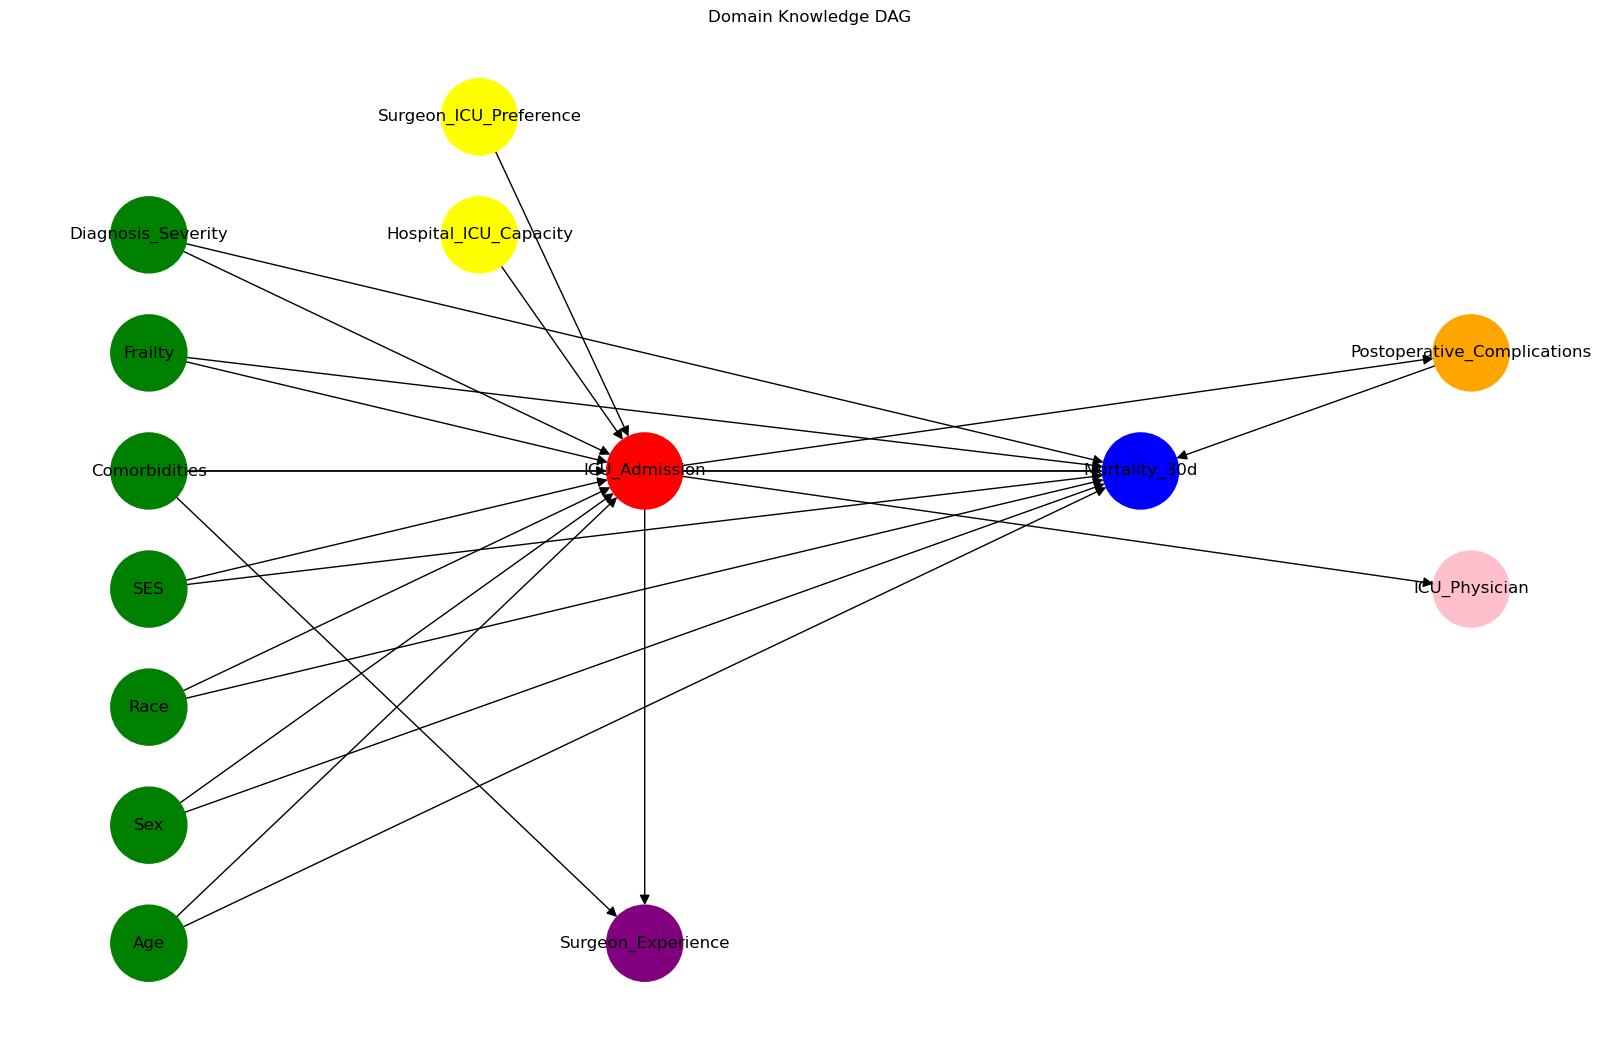

In [6]:
color_map = []

for node in G_domain.nodes():

    if node in treatment:
        color_map.append("red")

    elif node in outcome:
        color_map.append("blue")

    elif node in confounders:
        color_map.append("green")

    elif node in mediators:
        color_map.append("orange")

    elif node in colliders:
        color_map.append("purple")

    elif node in instrumental_vars:
        color_map.append("yellow")

    elif node in post_treatment:
        color_map.append("pink")

    else:
        color_map.append("gray")

pos = {}

for i,node in enumerate(confounders):
    pos[node] = (-3,i)

for i,node in enumerate(instrumental_vars):
    pos[node] = (-1,6+i)

pos["ICU_Admission"] = (0,4)
pos["Mortality_30d"] = (3,4)

pos["Postoperative_Complications"] = (5,5)
pos["ICU_Physician"] = (5,3)

pos["Surgeon_Experience"] = (0,0)

plt.figure(figsize=(16,10))

nx.draw(
G_domain,
pos,
with_labels=True,
node_color=color_map,
node_size=3000,
font_size=12,
arrowsize=15
)

plt.title("Domain Knowledge DAG")

plt.show()

In [7]:
# Students should ask an LLM (e.g., ChatGPT) the following prompt:

"""
You are a clinical causal inference expert.

Construct a causal DAG describing how ICU admission affects 30-day mortality
for emergency surgery patients using the following variables:

Age, Sex, Race, SES, Comorbidities, Frailty, Diagnosis Severity,
Hospital ICU Capacity, Surgeon ICU Preference,
Postoperative Complications,
Surgeon Experience,
ICU Physician,
ICU Admission,
Mortality.

Identify confounders, mediators, colliders, and instrumental variables.

Return the DAG as a list of directed edges.
"""

'\nYou are a clinical causal inference expert.\n\nConstruct a causal DAG describing how ICU admission affects 30-day mortality\nfor emergency surgery patients using the following variables:\n\nAge, Sex, Race, SES, Comorbidities, Frailty, Diagnosis Severity,\nHospital ICU Capacity, Surgeon ICU Preference,\nPostoperative Complications,\nSurgeon Experience,\nICU Physician,\nICU Admission,\nMortality.\n\nIdentify confounders, mediators, colliders, and instrumental variables.\n\nReturn the DAG as a list of directed edges.\n'

In [8]:
# Example LLM-proposed edges (students replace with actual LLM output)

llm_edges = [
("Age","ICU_Admission"),
("Age","Mortality_30d"),
("Frailty","ICU_Admission"),
("Frailty","Mortality_30d"),
("Comorbidities","ICU_Admission"),
("Comorbidities","Mortality_30d"),
("ICU_Admission","Postoperative_Complications"),
("Postoperative_Complications","Mortality_30d"),
("ICU_Admission","Mortality_30d")
]

G_llm = nx.DiGraph()

G_llm.add_nodes_from(nodes)
G_llm.add_edges_from(llm_edges)

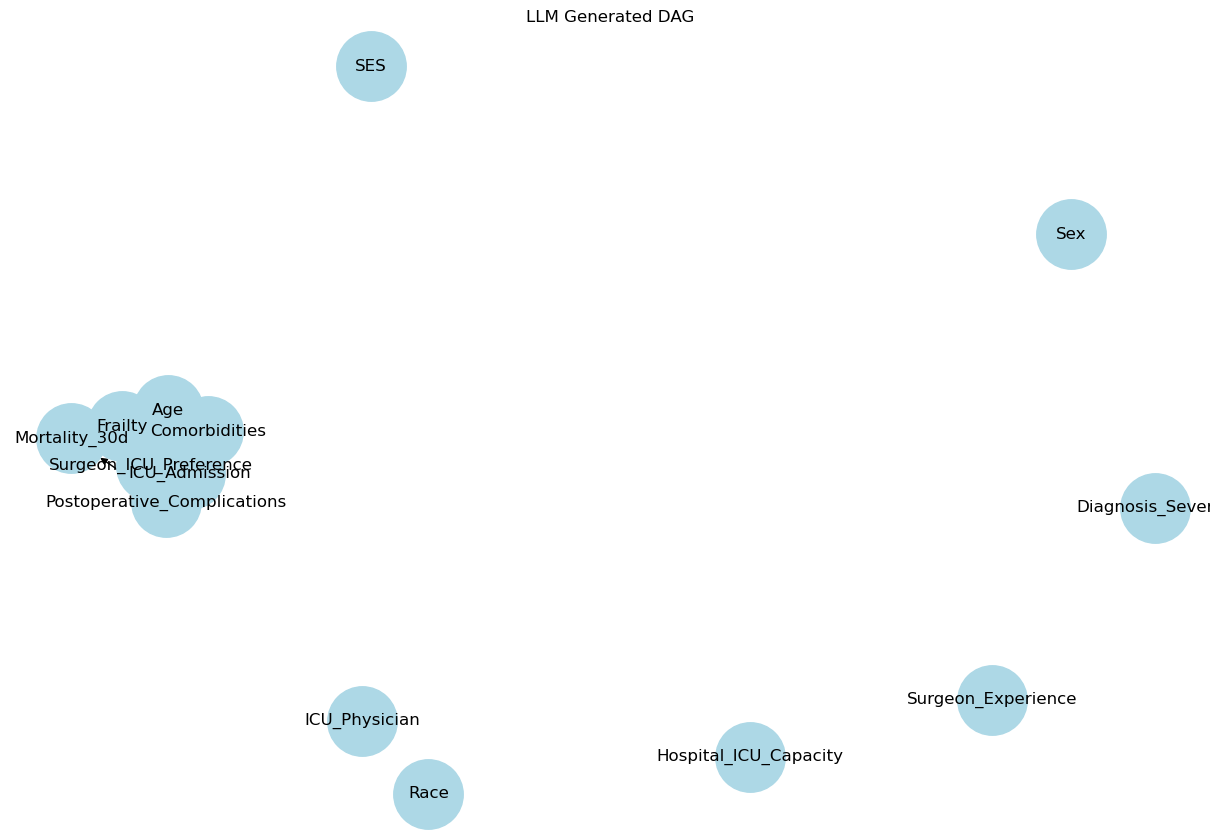

In [9]:
plt.figure(figsize=(12,8))

pos_llm = nx.spring_layout(G_llm, seed=42)

nx.draw(
G_llm,
pos_llm,
with_labels=True,
node_size=2500,
node_color="lightblue",
arrows=True
)

plt.title("LLM Generated DAG")

plt.show()

In [10]:
np.random.seed(42)

n = 15000

Age = np.random.normal(65,10,n)
Comorbidities = np.random.normal(2,1,n)
Frailty = np.random.normal(1,0.5,n)
Severity = np.random.normal(0,1,n)

Hospital_ICU_Capacity = np.random.normal(0,1,n)
Surgeon_Preference = np.random.normal(0,1,n)

logit = 0.03*Age + 0.6*Severity + 0.5*Comorbidities + 0.7*Hospital_ICU_Capacity

p_T = 1/(1+np.exp(-logit))

ICU_Admission = np.random.binomial(1,p_T)

Complications = 0.5*Severity + 0.3*Comorbidities + np.random.normal(0,1,n)

Mortality = (
0.8*Severity
+0.4*Frailty
+0.5*Complications
-0.6*ICU_Admission
+np.random.normal(0,1,n)
)

data = pd.DataFrame({
"Age":Age,
"Comorbidities":Comorbidities,
"Frailty":Frailty,
"Diagnosis_Severity":Severity,
"Hospital_ICU_Capacity":Hospital_ICU_Capacity,
"Surgeon_ICU_Preference":Surgeon_Preference,
"ICU_Admission":ICU_Admission,
"Postoperative_Complications":Complications,
"Mortality_30d":Mortality
})

In [11]:
model = CausalModel(
data=data,
treatment="ICU_Admission",
outcome="Mortality_30d"
)

identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
identified_estimand,
method_name="backdoor.linear_regression"
)

print("Estimated Treatment Effect:", estimate.value)

Estimated Treatment Effect: 0.08253283145164102


In [18]:
from pgmpy.estimators import PC

pc = PC(data)

model_pc = pc.estimate(
    ci_test="pearsonr",
    significance_level=0.05,
    show_progress=False
)

import networkx as nx

G_pc = nx.DiGraph(model_pc.edges())


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age': 'N', 'Comorbidities': 'N', 'Frailty': 'N', 'Diagnosis_Severity': 'N', 'Hospital_ICU_Capacity': 'N', 'Surgeon_ICU_Preference': 'N', 'ICU_Admission': 'N', 'Postoperative_Complications': 'N', 'Mortality_30d': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy:Reached maximum number of allowed conditional variables. Exiting


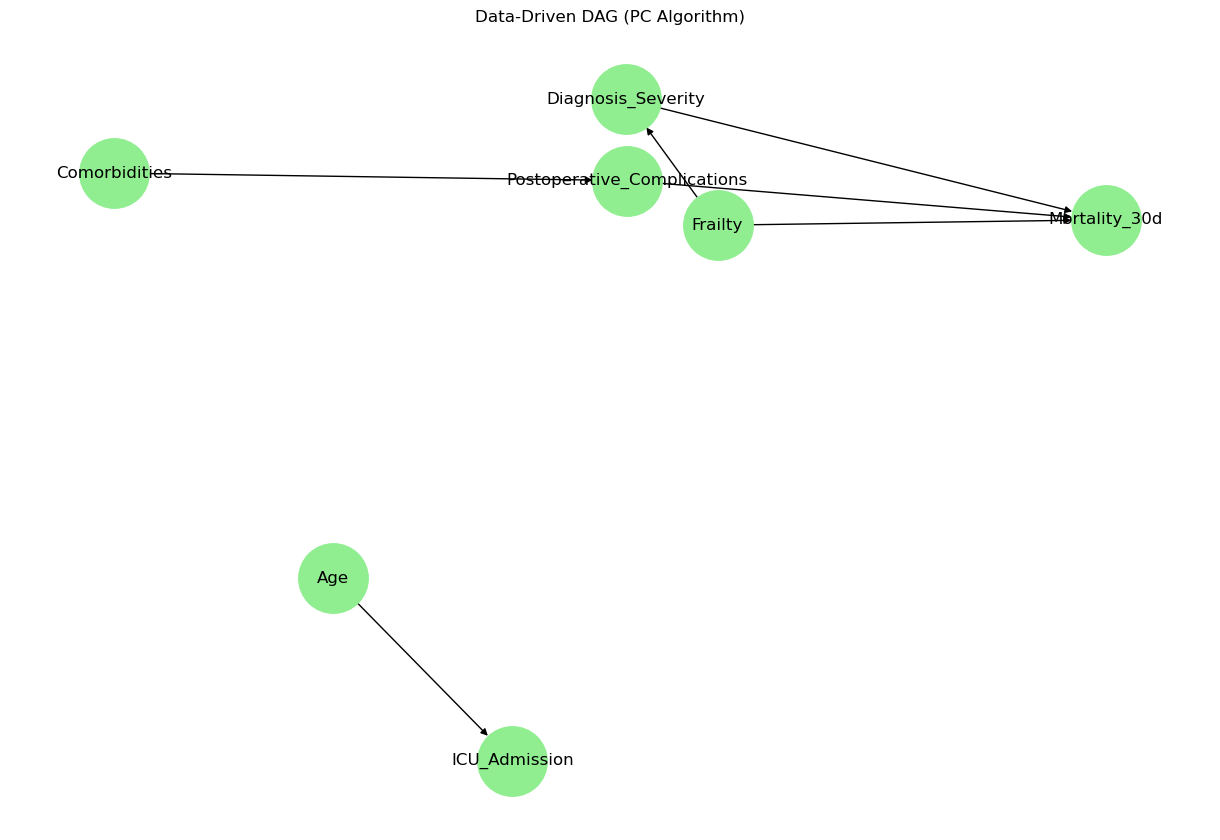

In [19]:
plt.figure(figsize=(12,8))

pos_pc = nx.spring_layout(G_pc, seed=42)

nx.draw(
G_pc,
pos_pc,
with_labels=True,
node_size=2500,
node_color="lightgreen",
arrows=True
)

plt.title("Data-Driven DAG (PC Algorithm)")

plt.show()

In [20]:
print("Number of edges")

print("Domain DAG:", len(G_domain.edges()))
print("LLM DAG:", len(G_llm.edges()))
print("PC Algorithm DAG:", len(G_pc.edges()))

Number of edges
Domain DAG: 22
LLM DAG: 9
PC Algorithm DAG: 6
